## Decision Trees

Primeiro vamos carregar alguns dados fabricados sobre contratações passadas que eu inventei. Note como usamos o pandas para converter um arquivo csv em um DataFrame:

In [2]:
import numpy as np
import pandas as pd
from sklearn import tree #biblioteca tree

#lendo o arquivo csv
input_file = "C:/Users/zinho/OneDrive/Documentos/Lamia/Card 13 - Predição e a Base de Aprendizado de Máquina (II)/PastHires.csv"
df = pd.read_csv(input_file, header = 0) #criando um DataFrame

df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


O scikit-learn precisa que tudo seja numérico para as árvores de decisão funcionarem. Então, vamos mapear Y,N para 1,0 e os níveis de educação para uma escala de 0-2. No mundo real, você precisaria pensar em como lidar com dados inesperados ou ausentes! Ao usar map(), sabemos que vamos obter NaN para valores inesperados.

In [9]:
d = {'Y': 1, 'N': 0}
df['Hired'] = df['Hired'].map(d)
df['Employed?'] = df['Employed?'].map(d)
df['Top-tier school'] = df['Top-tier school'].map(d)
df['Interned'] = df['Interned'].map(d)
#crinado um modelo como arvore de decisao, trasformando dados categoricos em numerico
d = {'BS': 0, 'MS': 1, 'PhD': 2}
df['Level of Education'] = df['Level of Education'].map(d)

df.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,1
1,0,0,0,0,1,1,1
2,7,0,6,0,0,0,0
3,2,1,1,1,1,0,1
4,20,0,2,2,1,0,0


Em seguida, precisamos separar as features da coluna-alvo para a qual estamos tentando construir uma árvore de decisão.

In [10]:
features = list(df.columns[:6]) #lista com os 6 primeiras colunas da tabela
print(features)

['Years Experience', 'Employed?', 'Previous employers', 'Level of Education', 'Top-tier school', 'Interned']


Agora vamos de fato construir a árvore de decisão:

In [11]:
y = df["Hired"]
X = df[features]
clf = tree.DecisionTreeClassifier()  #aqui que treina os padroes dos dados
clf = clf.fit(X, y)

... e exibi-la. Note que você precisa ter o pydotplus instalado para isso funcionar.

Para ler essa árvore de decisão, cada condição se ramifica para a esquerda em caso de "verdadeiro" e para a direita em caso de "falso". Quando você chega a um valor, o array value representa quantas amostras existem em cada valor-alvo. Ou seja, value = [0. 5.] significa que existem 0 "não contratados" e 5 "contratados" até chegar naquele ponto. value = [3. 0.] significa 3 não contratados e 0 contratados.

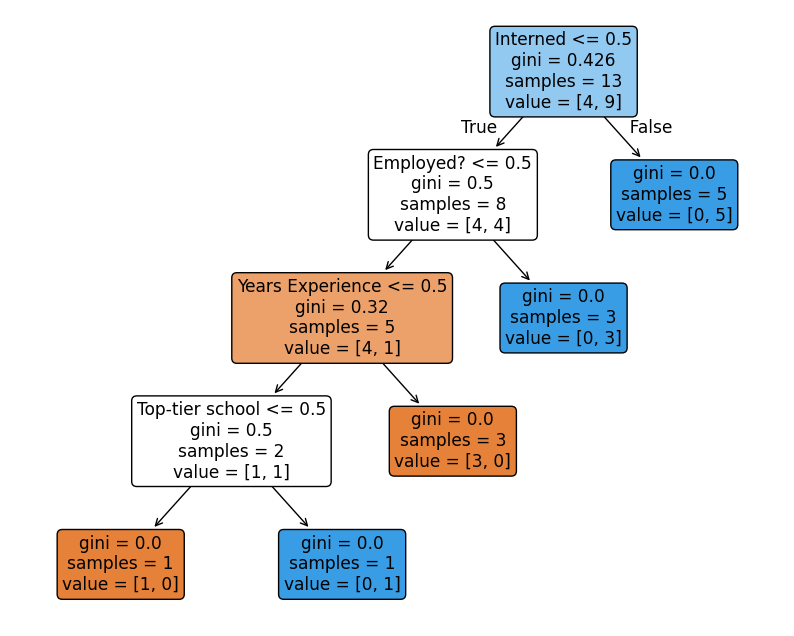

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
tree.plot_tree(clf, feature_names=features, filled=True, rounded=True) #renderiza a estrutura das decisoes, mostrando os caminhos que o algoritmo toma (verdadeiro/falso) para decidir se contrata ou n.
plt.show()

## Ensemble Learning: usando uma random forest

Vamos usar uma random forest de 10 árvores de decisão para prever a contratação de perfis específicos de candidatos:

In [14]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

clf = RandomForestClassifier(n_estimators=10)
clf = clf.fit(X, y)

# Transformando os dados de teste em um DataFrame com os nomes das colunas corretos
candidato_empregado = pd.DataFrame([[10, 1, 4, 0, 0, 0]], columns=features)
candidato_desempregado = pd.DataFrame([[10, 0, 4, 0, 0, 0]], columns=features)

#usa o modelo para prever se eles seriam contratados. para empregado e desempregado
print(clf.predict(candidato_empregado))
print(clf.predict(candidato_desempregado))

[1]
[1]


## Atividade

Modifique os dados de teste para criar um universo alternativo onde eu contrato todo mundo que normalmente eu não contrataria, e vice-versa. Compare a árvore de decisão resultante com a dos dados originais.

In [15]:
# Criando uma copia do DataFrame 
df_bizarro = df.copy()

#invertendo a coluna hired o que era 1 vira 0, o que era 0 vira 1
df_bizarro['Hired'] = 1 - df_bizarro['Hired']

df_bizarro.head()

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,0
1,0,0,0,0,1,1,0
2,7,0,6,0,0,0,1
3,2,1,1,1,1,0,0
4,20,0,2,2,1,0,1


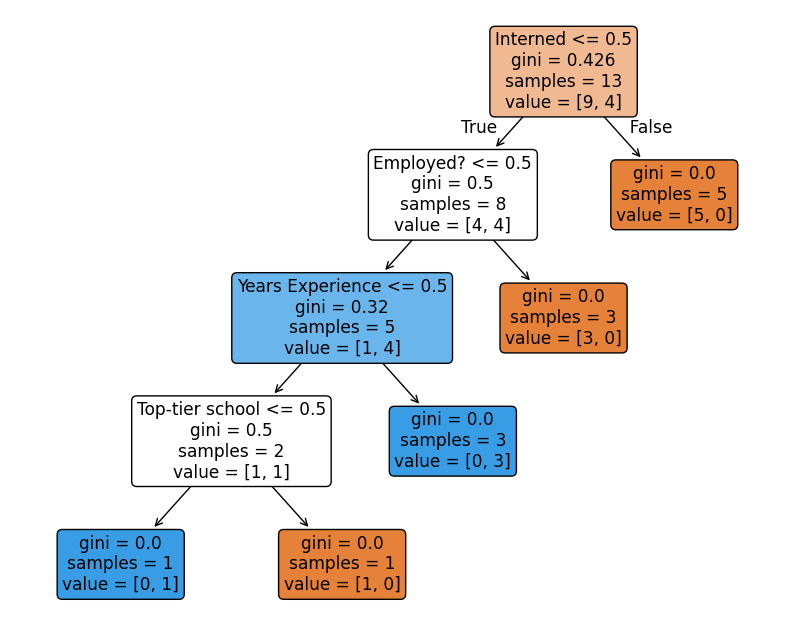

In [16]:
#separando features (X) do target invertido (y_bizarro)
y_bizarro = df_bizarro["Hired"]
X_bizarro = df_bizarro[features]

# Construindo a nova arvore
clf_bizarro = tree.DecisionTreeClassifier()
clf_bizarro = clf_bizarro.fit(X_bizarro, y_bizarro)

# Plotando a nova árvore de decisão
plt.figure(figsize=(10, 8))
tree.plot_tree(clf_bizarro, feature_names=features, filled=True, rounded=True)
plt.show()

# Conclusão:
# Ao comparar essa árvore com a primeira, você notará que a estrutura de decisão 
# se manteve muito parecida ou simétrica, mas os caminhos levam aos resultados opostos!
# Onde antes a árvore classificava como "contratado" (valor concentrado à direita da lista),
# agora ela joga o peso para "não contratado" (valor concentrado à esquerda).

In [ ]:
pip install 